## Fig 4 PCA

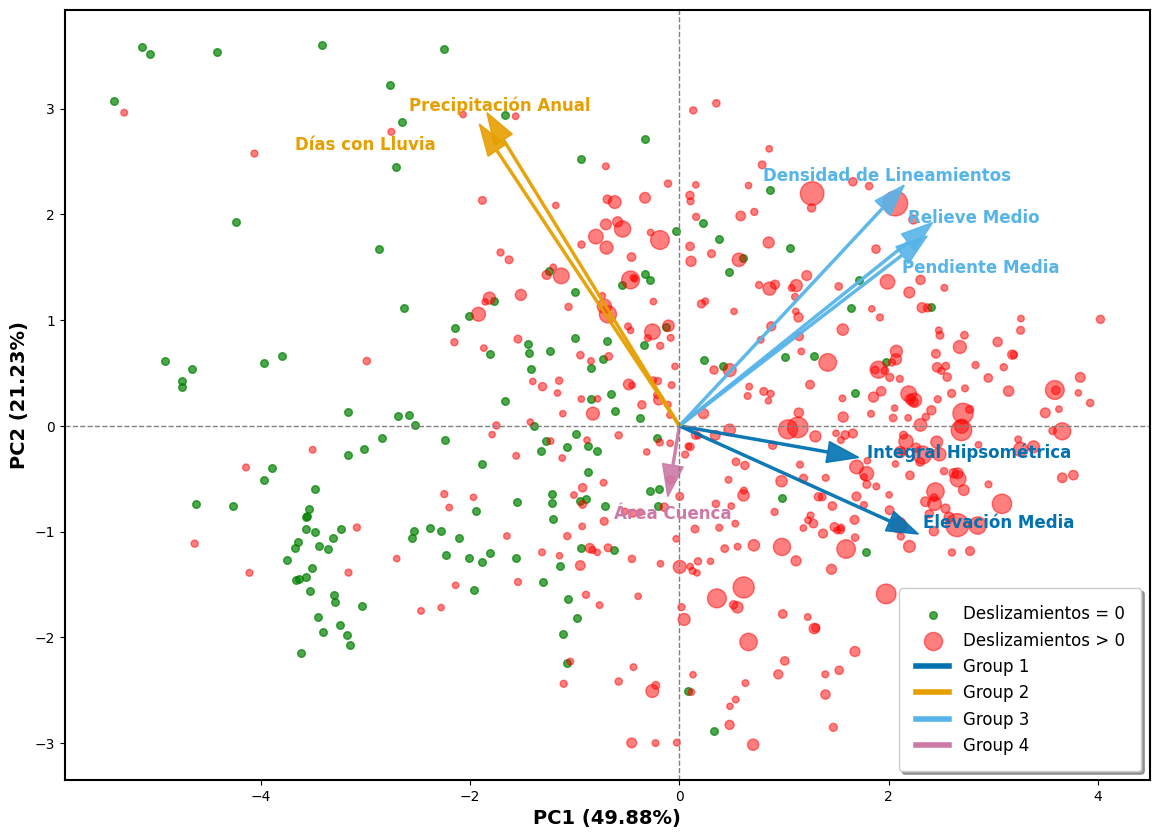

In [9]:
import geopandas as gpd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# Cargar el archivo geopackage en un GeoDataFrame
# Asegúrate de que la ruta al archivo sea correcta
file_path = "/home/edier/GoogleDrive/INVESTIGACION/PAPERS/ELABORACION/PAPER_SAR/Data/df_catchments_kmeans.gpkg"
try:
    gdf = gpd.read_file(file_path)
except Exception as e:
    print(f"Error al cargar el archivo: {e}")
    # Crear un DataFrame de ejemplo si el archivo no se encuentra, para que el script pueda ejecutarse
    print("Creando un DataFrame de ejemplo para demostración.")
    data = {
        'area': [10, 12, 15, 8, 9, 20, 22, 18, 5, 7],
        'hypso_inte': [0.5, 0.6, 0.4, 0.7, 0.55, 0.45, 0.3, 0.8, 0.65, 0.75],
        'Densidad': [1.2, 1.5, 1.1, 1.8, 1.3, 1.0, 0.9, 2.0, 1.6, 1.9],
        'rainfallAnnual_mean': [1200, 1500, 1100, 1800, 1300, 1000, 900, 2000, 1600, 1900],
        'elev_mean': [500, 600, 450, 700, 550, 400, 300, 800, 650, 750],
        'slope_mean': [25, 30, 22, 35, 28, 20, 18, 40, 32, 38],
        'rel_mean': [100, 120, 90, 150, 110, 80, 70, 180, 130, 160],
        'RainfallDaysmean': [150, 160, 140, 180, 155, 130, 120, 200, 170, 190],
        'lands_rec': [1, 5, 0, 8, 2, 0, 0, 12, 4, 0]
    }
    gdf = gpd.GeoDataFrame(pd.DataFrame(data), geometry=gpd.points_from_xy(range(10), range(10)))


# Definir el subconjunto de variables para el análisis PCA
selected_columns_updated = ['area', 'hypso_inte', 'Densidad', 'rainfallAnnual_mean', 'elev_mean', 'slope_mean', 'rel_mean', 'RainfallDaysmean']

# Filtrar los datos para incluir solo las columnas seleccionadas
data_subset_updated = gdf[selected_columns_updated]

# Estandarizar los datos antes de aplicar PCA
scaler = StandardScaler()
data_scaled_subset_updated = scaler.fit_transform(data_subset_updated)

# Aplicar Análisis de Componentes Principales (PCA)
pca_subset_updated = PCA(n_components=3)  # Extraer 3 componentes principales
principal_components_subset_updated = pca_subset_updated.fit_transform(data_scaled_subset_updated)

# Crear un DataFrame con los componentes principales
pca_subset_updated_df = pd.DataFrame(data=principal_components_subset_updated, columns=['PC1', 'PC2', 'PC3'])

# Extraer las cargas (loadings) para las variables
loadings_subset_updated = pca_subset_updated.components_.T[:, :2]

# Calcular el porcentaje de varianza explicada para PC1 y PC2
explained_variance_subset_updated = pca_subset_updated.explained_variance_ratio_
pc1_explained_variance = explained_variance_subset_updated[0] * 100
pc2_explained_variance = explained_variance_subset_updated[1] * 100

# --- INICIO DE LA MODIFICACIÓN: DEFINICIÓN DE GRUPOS DE VECTORES ---

# 1. Define tus 4 grupos de variables aquí. Puedes cambiar los nombres y qué variables pertenecen a cada grupo.
#    He creado una agrupación de ejemplo basada en la naturaleza de las variables.
variable_groups = {
    'Group 1': ['hypso_inte', 'elev_mean'],
    'Group 2': ['rainfallAnnual_mean', 'RainfallDaysmean'],
    'Group 3': ['Densidad', 'slope_mean', 'rel_mean'],
    'Group 4': ['area']
}

# 2. Asigna un color a cada grupo.
group_colors = {
    'Group 1': '#0072B2',  # Azul oscuro
    'Group 2': '#E69F00',  # Naranja/Oro
    'Group 3': '#56B4E9',  # Cian/Azul claro
    'Group 4': '#CC79A7'   # Magenta
}

# Crear un mapeo inverso de variable a nombre de grupo para un fácil acceso
variable_to_group = {var: group for group, variables in variable_groups.items() for var in variables}

# --- FIN DE LA MODIFICACIÓN ---

# Definir el tamaño de cada punto basado en la columna "lands_rec"
size_column = gdf['lands_rec']
# Escalar los tamaños para una mejor visualización
size_scaled = (size_column - size_column.min()) / (size_column.max() - size_column.min()) * 300 + 20

# Crear máscaras para lands_rec igual a cero y mayor que cero
zero_mask = size_column == 0
non_zero_mask = size_column > 0

# Iniciar el gráfico
plt.figure(figsize=(14, 10))

# Graficar puntos con 'lands_rec' = 0 (círculos verdes)
plt.scatter(pca_subset_updated_df['PC1'][zero_mask], pca_subset_updated_df['PC2'][zero_mask],
            s=30, alpha=0.7, color='green', marker='o', label='Deslizamientos = 0')

# Graficar puntos con 'lands_rec' > 0 (círculos rojos)
plt.scatter(pca_subset_updated_df['PC1'][non_zero_mask], pca_subset_updated_df['PC2'][non_zero_mask],
            s=size_scaled[non_zero_mask], alpha=0.5, color='red', marker='o', label='Deslizamientos > 0')

# Etiquetas para los ejes
plt.xlabel(f'PC1 ({pc1_explained_variance:.2f}%)', fontsize=14, weight='bold')
plt.ylabel(f'PC2 ({pc2_explained_variance:.2f}%)', fontsize=14, weight='bold')

# Coordenadas para las etiquetas de los vectores (ajustar si es necesario)
label_coordinates = {
    'area': (loadings_subset_updated[0, 0] * 1.02, loadings_subset_updated[0, 1] * 2.22),
    'hypso_inte': (loadings_subset_updated[1, 0] * 1.95, loadings_subset_updated[1, 1] * 1.02),
    'Densidad': (loadings_subset_updated[2, 0] * 1.02, loadings_subset_updated[2, 1] * 1.15),
    'rainfallAnnual_mean': (loadings_subset_updated[3, 0] * 1.02, loadings_subset_updated[3, 1] * 1.12),
    'elev_mean': (loadings_subset_updated[4, 0] * 1.52, loadings_subset_updated[4, 1] * 1.02),
    'slope_mean': (loadings_subset_updated[5, 0] * 1.32, loadings_subset_updated[5, 1] * 0.86),
    'rel_mean': (loadings_subset_updated[6, 0] * 1.32, loadings_subset_updated[6, 1] * 1.22),
    'RainfallDaysmean': (loadings_subset_updated[7, 0] * 1.72, loadings_subset_updated[7, 1] * 1.02)
}

# Nombres personalizados para las etiquetas de los vectores
label_names = {
    'area': 'Área Cuenca',
    'hypso_inte': 'Integral Hipsométrica',
    'Densidad': 'Densidad de Lineamientos',
    'rainfallAnnual_mean': 'Precipitación Anual',
    'elev_mean': 'Elevación Media',
    'slope_mean': 'Pendiente Media',
    'rel_mean': 'Relieve Medio',
    'RainfallDaysmean': 'Días con Lluvia'
}

# Factor de escalado para hacer los vectores más visibles
scaling_factor = 5

# Añadir los vectores, ahora coloreados por grupo
for i, column in enumerate(selected_columns_updated):
    arrow_x = loadings_subset_updated[i, 0] * scaling_factor
    arrow_y = loadings_subset_updated[i, 1] * scaling_factor
    label_x, label_y = label_coordinates[column]
    label_name = label_names.get(column, column)

    # --- MODIFICACIÓN: OBTENER EL COLOR DEL GRUPO ---
    group_name = variable_to_group.get(column, 'Default')
    arrow_color = group_colors.get(group_name, 'black') # Color negro por defecto si no se encuentra el grupo
    
    # Dibujar la flecha con el color del grupo
    plt.arrow(0, 0, arrow_x, arrow_y,
              color=arrow_color, alpha=0.9, head_width=0.2, width=0.02)
    
    # Escribir el texto con el color del grupo
    plt.text(label_x * scaling_factor, label_y * scaling_factor,
             label_name, color=arrow_color, ha='center', va='center', fontsize=12, weight='bold')

# Eliminar la cuadrícula
plt.grid(False)

# Añadir líneas de referencia
plt.axhline(0, color='grey', linestyle='--', lw=1)
plt.axvline(0, color='grey', linestyle='--', lw=1)

# --- MODIFICACIÓN: CREAR LEYENDA COMBINADA ---
# Obtener las manijas y etiquetas de la leyenda de los puntos (scatter)
handles, labels = plt.gca().get_legend_handles_labels()

# Crear elementos de leyenda para los grupos de vectores
vector_legend_elements = [Line2D([0], [0], color=color, lw=4, label=group)
                          for group, color in group_colors.items()]

# Combinar ambas leyendas
all_handles = handles + vector_legend_elements
plt.legend(handles=all_handles, fontsize=12, frameon=True, title_fontsize='13', shadow=True, borderpad=1)

# Añadir bordes al gráfico
for spine in plt.gca().spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(1.5)

# Guardar la figura
plt.savefig('/home/edier/GoogleDrive/INVESTIGACION/PAPERS/ELABORACION/PAPER_SAR/Figures/figFinal/Fig4.png', dpi=500, bbox_inches='tight')
plt.show()
